In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# Load data
df = pd.read_csv("ppi.csv")

In [3]:
# Train/validation/test split by protein
unique_proteins = df["uniprot_id"].unique()

train_val_ids, test_ids = train_test_split(
    unique_proteins,
    test_size=0.20,
    random_state=22
)

train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=0.25,
    random_state=23
)

train_data = df[df["uniprot_id"].isin(train_ids)].copy()
val_data = df[df["uniprot_id"].isin(val_ids)].copy()
test_data = df[df["uniprot_id"].isin(test_ids)].copy()

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (38261, 138)
Validation shape: (13385, 138)
Test shape: (13504, 138)


In [4]:
# Feature sets
length_feature = ["normalized_length"]

base_features = [
    "normalized_abs_surf_acc",
    "normalized_hydropathy_index",
    "rel_surf_acc",
    "prob_sheet",
    "prob_helix",
    "prob_coil"
] + [c for c in df.columns if c.startswith("pssm_") and "_wm_" not in c]

feature_sets = {
    "Model 1: Base + Length": length_feature + base_features,
    "Model 2: Window 3 + Length": length_feature + [c for c in df.columns if c.startswith("3_wm_")],
    "Model 3: Window 5 + Length": length_feature + [c for c in df.columns if c.startswith("5_wm_")],
    "Model 4: Window 7 + Length": length_feature + [c for c in df.columns if c.startswith("7_wm_")],
    "Model 5: Window 9 + Length": length_feature + [c for c in df.columns if c.startswith("9_wm_")]
}

In [5]:
# RF undersampling pipeline
rus = RandomUnderSampler(random_state=33)

rf_pipeline = Pipeline([
    ("resampler", rus),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        max_features="sqrt",
        min_samples_split=2,
        random_state=66,
        n_jobs=-1
    ))
])

In [6]:
# Metrics and cross-validation
scoring = {
    "MCC": make_scorer(matthews_corrcoef),
    "F1": make_scorer(f1_score, zero_division=0),
    "ROC-AUC": "roc_auc",
    "Bal.Acc": make_scorer(balanced_accuracy_score),
    "Precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
# Cross-validation for all RF models
output_dir = "model_outputs"
os.makedirs(output_dir, exist_ok=True)

final_results = []
saved_files_registry = []

for model_name, features in feature_sets.items():
    print(f"Testing {model_name}...")
    
    X_train_sub = train_data[features]
    y_train = train_data["p_interface"]
    
    y_prob = cross_val_predict(
        rf_pipeline,
        X_train_sub,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
    
    y_pred = (y_prob >= 0.5).astype(int)
    
    safe_model = model_name.replace(" ", "_").replace(":", "").replace("+", "plus")
    filename = f"{safe_model}_RF_Undersampled.csv"
    file_path = os.path.join(output_dir, filename)
    
    pd.DataFrame({
        "y_true": y_train,
        "y_prob": y_prob,
        "y_pred": y_pred
    }).to_csv(file_path, index=False)
    
    saved_files_registry.append((model_name, file_path))
    
    scores = cross_validate(
        rf_pipeline,
        X_train_sub,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    final_results.append({
        "Model": model_name,
        "Config": "RF (Undersampled)",
        "MCC": np.mean(scores["test_MCC"]).round(3),
        "F1": np.mean(scores["test_F1"]).round(3),
        "AUC": np.mean(scores["test_ROC-AUC"]).round(3),
        "Bal.Acc": np.mean(scores["test_Bal.Acc"]).round(3),
        "Precision": np.mean(scores["test_Precision"]).round(3),
        "Recall": np.mean(scores["test_Recall"]).round(3)
    })

print("\n--- DONE: Files saved to model_outputs/ ---")

Testing Model 1: Base + Length...
Testing Model 2: Window 3 + Length...
Testing Model 3: Window 5 + Length...
Testing Model 4: Window 7 + Length...
Testing Model 5: Window 9 + Length...

--- DONE: Files saved to model_outputs/ ---


In [8]:
# Summary table
results_df = pd.DataFrame(final_results)
print("\n--- FINAL CROSS-VALIDATION RESULTS ---")
print(results_df.to_string(index=False))


--- FINAL CROSS-VALIDATION RESULTS ---
                     Model            Config   MCC    F1   AUC  Bal.Acc  Precision  Recall
    Model 1: Base + Length RF (Undersampled) 0.222 0.320 0.728    0.667      0.210   0.670
Model 2: Window 3 + Length RF (Undersampled) 0.263 0.347 0.765    0.697      0.229   0.716
Model 3: Window 5 + Length RF (Undersampled) 0.307 0.379 0.800    0.726      0.254   0.746
Model 4: Window 7 + Length RF (Undersampled) 0.341 0.402 0.824    0.750      0.271   0.782
Model 5: Window 9 + Length RF (Undersampled) 0.367 0.423 0.845    0.768      0.287   0.801


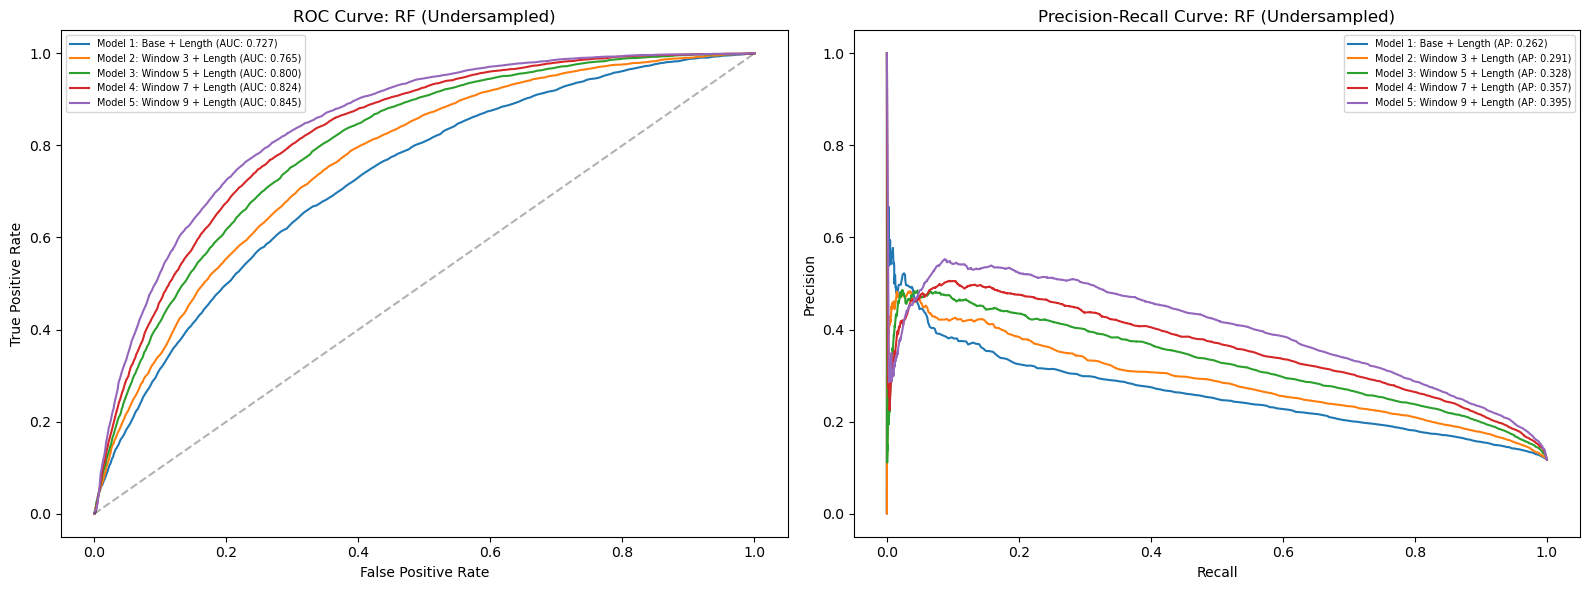

In [9]:
# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for model_label, path in saved_files_registry:
    if not os.path.exists(path):
        continue
    
    data = pd.read_csv(path)
    y_true = data["y_true"]
    y_prob = data["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax1.plot(fpr, tpr, label=f"{model_label} (AUC: {auc(fpr, tpr):.3f})")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax2.plot(recall, precision, label=f"{model_label} (AP: {ap:.3f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax1.set_title("ROC Curve: RF (Undersampled)")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(fontsize="x-small")

ax2.set_title("Precision-Recall Curve: RF (Undersampled)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize="x-small")

plt.tight_layout()
plt.show()

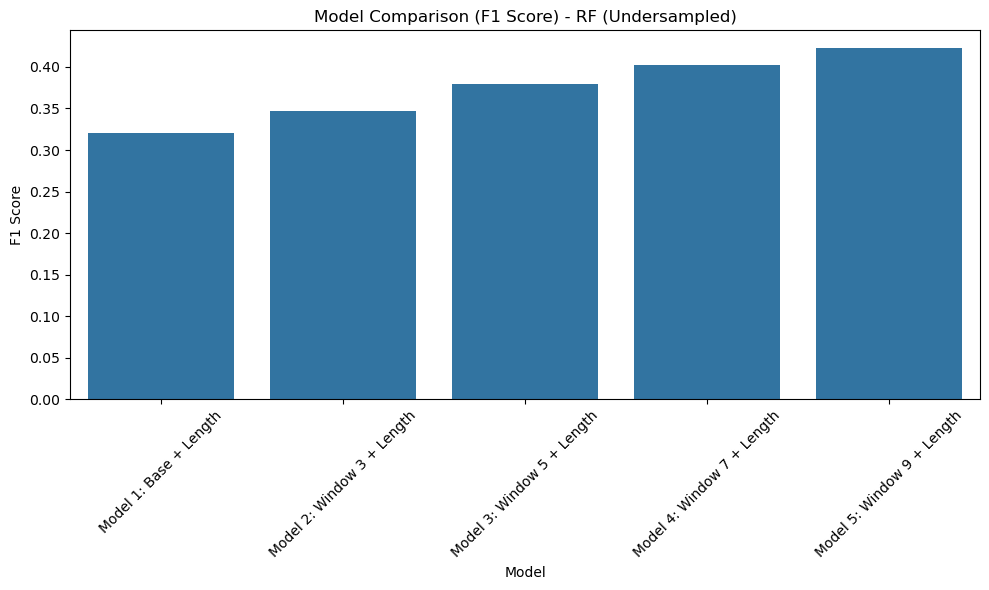

In [10]:
# F1 plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title("Model Comparison (F1 Score) - RF (Undersampled)")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

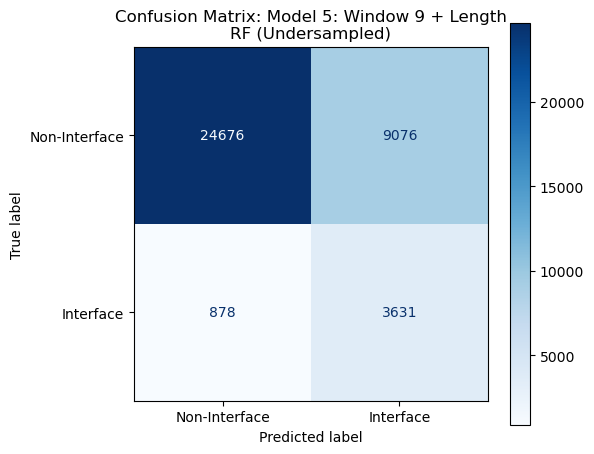

In [11]:
# Confusion matrix for final model
target_model = "Model 5: Window 9 + Length"
target_file = os.path.join(
    output_dir,
    f"{target_model.replace(' ', '_').replace(':', '').replace('+', 'plus')}_RF_Undersampled.csv"
)

if os.path.exists(target_file):
    data = pd.read_csv(target_file)

    y_true = data["y_true"]
    y_pred = data["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Interface", "Interface"]
    )
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix: {target_model}\nRF (Undersampled)")
    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {target_file}")

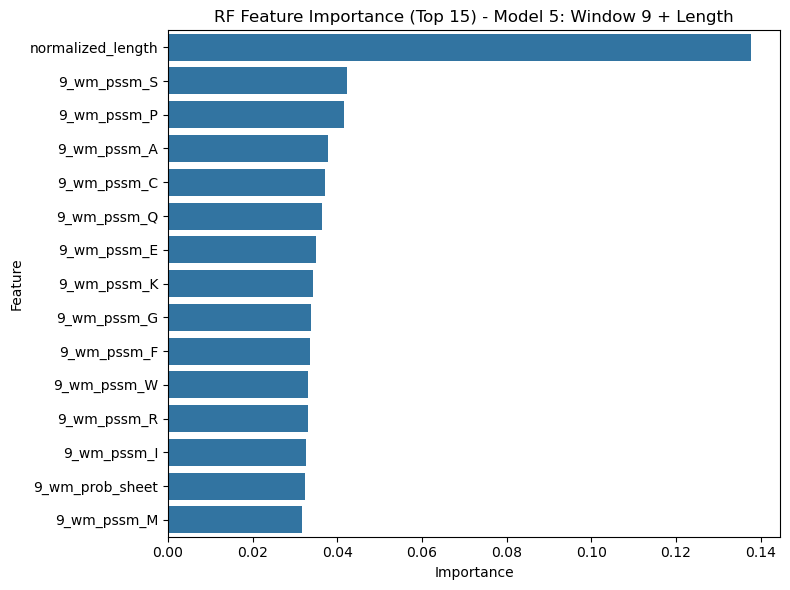

In [12]:
# Feature importance for final model
target_model = "Model 5: Window 9 + Length"
best_features = feature_sets[target_model]

X_best = train_data[best_features]
y_full = train_data["p_interface"]

rf_pipeline.fit(X_best, y_full)
rf_model = rf_pipeline.named_steps["model"]

rf_importance = pd.DataFrame({
    "Feature": X_best.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance.head(15), x="Importance", y="Feature")
plt.title(f"RF Feature Importance (Top 15) - {target_model}")
plt.tight_layout()
plt.show()

In [13]:
# Error analysis for final model
y_pred_rf = cross_val_predict(
    rf_pipeline,
    X_best,
    y_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

def error_analysis(df_features, y_true, y_pred, feature_list):
    temp = df_features.copy()
    temp["y_true"] = np.array(y_true)
    temp["y_pred"] = np.array(y_pred)

    results = []

    for f in feature_list:
        tp = temp[(temp["y_true"] == 1) & (temp["y_pred"] == 1)][f]
        fn = temp[(temp["y_true"] == 1) & (temp["y_pred"] == 0)][f]
        fp = temp[(temp["y_true"] == 0) & (temp["y_pred"] == 1)][f]

        results.append({
            "Feature": f,
            "TP_mean": tp.mean(),
            "FN_mean": fn.mean(),
            "FP_mean": fp.mean(),
            "Δ_FN-TP": fn.mean() - tp.mean()
        })

    return pd.DataFrame(results)

rf_top15 = rf_importance.head(15)["Feature"].tolist()

error_rf = error_analysis(X_best, y_full, y_pred_rf, rf_top15)
error_rf = error_rf.set_index("Feature").reindex(rf_top15).reset_index()
error_rf.reset_index(drop=True, inplace=True)

print("\n--- RF ERROR ANALYSIS (Top 15 features, SAME ORDER AS PLOT) ---")
display(error_rf.round(3))


--- RF ERROR ANALYSIS (Top 15 features, SAME ORDER AS PLOT) ---


,Feature,TP_mean,FN_mean,FP_mean,Δ_FN-TP
0,normalized_length,0.327,0.584,0.321,0.257
1,9_wm_pssm_S,0.352,0.378,0.337,0.026
2,9_wm_pssm_P,0.221,0.248,0.208,0.027
3,9_wm_pssm_A,0.352,0.376,0.355,0.024
4,9_wm_pssm_C,0.159,0.194,0.161,0.035
5,9_wm_pssm_Q,0.350,0.376,0.347,0.026
6,9_wm_pssm_E,0.352,0.369,0.357,0.017
7,9_wm_pssm_K,0.324,0.354,0.328,0.030
8,9_wm_pssm_G,0.232,0.245,0.227,0.013
9,9_wm_pssm_F,0.245,0.259,0.245,0.015


In [14]:
# Ablation study
full_model_features = feature_sets["Model 5: Window 9 + Length"]

pssm_9wm = [c for c in full_model_features if c.startswith("9_wm_pssm_")]
surface_9wm = [c for c in full_model_features if c in ["9_wm_normalized_abs_surf_acc", "9_wm_rel_surf_acc"]]
ss_9wm = [c for c in full_model_features if c in ["9_wm_prob_helix", "9_wm_prob_sheet", "9_wm_prob_coil"]]
hydro_9wm = [c for c in full_model_features if c == "9_wm_normalized_hydropathy_index"]
length_only = ["normalized_length"]

ablation_feature_sets = {
    "Full model": full_model_features,
    "- Length": [c for c in full_model_features if c not in length_only],
    "- PSSM": [c for c in full_model_features if c not in pssm_9wm],
    "- ASA/RSA": [c for c in full_model_features if c not in surface_9wm],
    "- Secondary structure": [c for c in full_model_features if c not in ss_9wm],
    "- Hydropathy": [c for c in full_model_features if c not in hydro_9wm]
}

ablation_results = []

for ablation_name, features in ablation_feature_sets.items():
    print(f"Running ablation: {ablation_name}")
    
    X_ablation = train_data[features]
    y_ablation = train_data["p_interface"]

    scores = cross_validate(
        rf_pipeline,
        X_ablation,
        y_ablation,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    ablation_results.append({
        "Model": ablation_name,
        "MCC": np.mean(scores["test_MCC"]).round(3),
        "F1": np.mean(scores["test_F1"]).round(3),
        "AUC": np.mean(scores["test_ROC-AUC"]).round(3),
        "Bal.Acc": np.mean(scores["test_Bal.Acc"]).round(3),
        "Precision": np.mean(scores["test_Precision"]).round(3),
        "Recall": np.mean(scores["test_Recall"]).round(3)
    })

ablation_df = pd.DataFrame(ablation_results)

print("\n--- ABLATION RESULTS ---")
display(ablation_df.round(3))

Running ablation: Full model
Running ablation: - Length
Running ablation: - PSSM
Running ablation: - ASA/RSA
Running ablation: - Secondary structure
Running ablation: - Hydropathy

--- ABLATION RESULTS ---


,Model,MCC,F1,AUC,Bal.Acc,Precision,Recall
0,Full model,0.367,0.423,0.845,0.768,0.287,0.801
1,- Length,0.280,0.349,0.797,0.715,0.222,0.806
2,- PSSM,0.287,0.363,0.783,0.713,0.241,0.738
3,- ASA/RSA,0.361,0.418,0.842,0.764,0.284,0.796
4,- Secondary structure,0.356,0.413,0.839,0.760,0.279,0.795
5,- Hydropathy,0.367,0.422,0.845,0.768,0.287,0.802


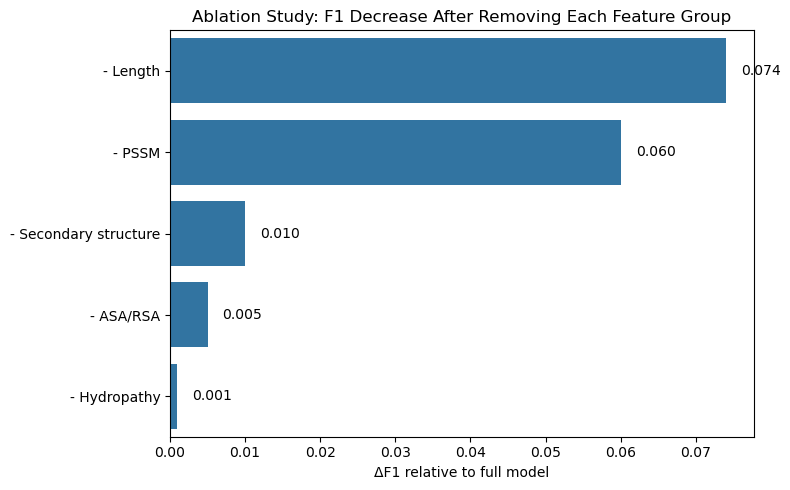

In [15]:
# Ablation figure: delta F1 relative to full model
full_f1 = ablation_df.loc[ablation_df["Model"] == "Full model", "F1"].values[0]

ablation_plot_df = ablation_df.copy()
ablation_plot_df["Delta_F1"] = full_f1 - ablation_plot_df["F1"]
ablation_plot_df = ablation_plot_df[ablation_plot_df["Model"] != "Full model"].copy()
ablation_plot_df = ablation_plot_df.sort_values("Delta_F1", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=ablation_plot_df,
    x="Delta_F1",
    y="Model"
)

for i, row in enumerate(ablation_plot_df.itertuples()):
    plt.text(row.Delta_F1 + 0.002, i, f"{row.Delta_F1:.3f}", va="center")

plt.title("Ablation Study: F1 Decrease After Removing Each Feature Group")
plt.xlabel("ΔF1 relative to full model")
plt.ylabel("")
plt.tight_layout()
plt.show()